# Phase 00–02 EDA — review of the downloaded data

Purpose: **verify the raw downloads before any science is computed from them.**
Each section says where the data comes from, shows the variables as downloaded,
maps the domain with political boundaries, and runs preliminary sanity checks.

| source | what | variables | cadence | extent | windows on disk |
|---|---|---|---|---|---|
| ERA5 via Google's **ARCO** mirror (public Zarr, anonymous) | reanalysis — best estimate of the real atmosphere | `u100`, `v100`, `ws100`, `sp` hourly; `z500` 6-hourly | hourly | Euro-Atlantic box 30–75°N, 40°W–40°E, 0.25° | Jan 2023; Nov–Dec 2024 |
| **SMARD** (Bundesnetzagentur API) | observed German feed-in + installed capacity | wind onshore, wind offshore, solar — MWh/interval converted to MW | hourly UTC | 4 TSO zones (50Hertz, TenneT, Amprion, TransnetBW) | Jan 2023; Nov–Dec 2024 |

Not yet downloaded: **EERIE IFS-FESOM2** (the coupled climate model — gated to Phase 06).
The two windows were chosen deliberately: Jan 2023 as a pipeline smoke test, Nov–Dec 2024
because it contains the well-documented German dark-lull events the project studies.


In [1]:
# Setup: load cached ERA5/SMARD data and define map styling with explicit coordinate labels.
import glob
import os
import pathlib
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
import yaml
from IPython.display import display
from matplotlib.ticker import FixedLocator

from eurogrid.data.smard import SmardClient, capacity_factor
from eurogrid.models.transfer import FLEET_BOXES

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))

PC = ccrs.PlateCarree()
WINDOWS = {"2023-01": ("2023-01-01", "2023-02-01"), "2024-11..12": ("2024-11-01", "2025-01-01")}
era5 = {
    w: xr.open_zarr(
        glob.glob(
            f"data/era5/era5_{datetime.fromisoformat(s):%Y%m%dT%H}"
            f"_{datetime.fromisoformat(e):%Y%m%dT%H}_*.zarr"
        )[0],
        consolidated=True,
    )
    for w, (s, e) in WINDOWS.items()
}


def map_ax(ax, title, borders=True):
    """Common map decoration with political boundaries and labelled coordinates."""
    ax.coastlines(resolution="50m", lw=0.7)
    if borders:
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, alpha=0.7)
    gl = ax.gridlines(draw_labels=True, linewidth=0.35, color="0.35", alpha=0.55, linestyle=":")
    gl.top_labels = gl.right_labels = False
    gl.xlocator = FixedLocator([-40, -20, 0, 20, 40])
    gl.ylocator = FixedLocator([30, 40, 50, 60, 70])
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = gl.ylabel_style = {"size": 8}
    ax.set_extent([-40, 40, 30, 75])
    ax.set_title(title, fontsize=10)
    return ax


era5.keys()

dict_keys(['2023-01', '2024-11..12'])

## 1. ERA5 — where it comes from and what was downloaded

ECMWF's hourly reanalysis at 0.25°, read from Google's ARCO mirror
(`gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3`).
The loader crops to the domain, wraps longitude to [−180°, 180°), keeps latitude
descending, and writes a local Zarr — the files in `data/era5/`.

**Variables and why each one exists in this project:**
- `u100`, `v100` — eastward/northward wind at 100 m (turbine hub height).
- `ws100` — 100 m wind speed = hypot(u100, v100); the wind resource itself.
- `sp` — surface pressure; needed later to flag where a climate-model pressure level sits below ground.
- `z500` — geopotential height of the 500 hPa surface, on a separate 6-hourly `time_z500` axis
  (each hourly field costs a 37-level global chunk; the blocking index is a daily diagnostic, so 6 h suffices).
- **GHI is not in this download.** Global horizontal irradiance would require a radiation variable such as
  ERA5 `surface_solar_radiation_downwards`; this notebook contains no GHI field, so solar generation remains
  observed-only in the current baseline.


In [2]:
# Inventory: every variable in the cached ERA5 datasets — dims, shape, units, time range.
rows = []
for w, ds in era5.items():
    for v in ds.data_vars:
        da = ds[v]
        rows.append(
            {
                "window": w,
                "variable": v,
                "dims": str(da.dims),
                "shape": tuple(da.shape),
                "units": da.attrs.get("units"),
                "first": str(da[da.dims[0]].values[0])[:19],
                "last": str(da[da.dims[0]].values[-1])[:19],
            }
        )
pl.DataFrame(rows)

window,variable,dims,shape,units,first,last
str,str,str,list[i64],str,str,str
"""2023-01""","""sp""","""('time', 'lat', 'lon')""","[744, 181, 321]","""Pa""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""u100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""v100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""ws100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""z500""","""('time_z500', 'lat', 'lon')""","[124, 181, 321]","""m""","""2023-01-01T00:00:00""","""2023-01-31T18:00:00"""
"""2024-11..12""","""sp""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""Pa""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""u100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""v100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""ws100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""


### 1.1a Coordinates, grid spacing, and temporal completeness

Before interpreting a map or statistic, check the structure of the cached files themselves:

- Are latitude and longitude monotonic and in the canonical `[-180°, 180°)` convention?
- Is the grid really close to the advertised 0.25° spacing?
- Does the hourly time axis contain every expected hour, with no duplicates?
- Does the separate `z500` axis contain every expected 6-hourly timestep?

These are structural checks, not climate results. A physically plausible map cannot compensate for a broken coordinate or time axis.


In [3]:
# Check ERA5 coordinates, grid spacing, and hourly/6-hourly time-axis continuity.
era5_structure = []
for w, d in era5.items():
    for coord, expected_step in [("lat", 0.25), ("lon", 0.25)]:
        values = d[coord].values
        diffs = np.diff(values)
        era5_structure.append(
            {
                "window": w,
                "check": coord,
                "first": float(values[0]),
                "last": float(values[-1]),
                "n": values.size,
                "monotonic": bool(np.all(diffs > 0) or np.all(diffs < 0)),
                "median_step_deg": float(np.median(np.abs(diffs))),
                "max_step_error_deg": float(np.max(np.abs(np.abs(diffs) - expected_step))),
            }
        )
    for axis, expected_hours in [("time", 1), ("time_z500", 6)]:
        values = d[axis].values.astype("datetime64[h]")
        diffs = np.diff(values).astype("timedelta64[h]").astype(int)
        era5_structure.append(
            {
                "window": w,
                "check": axis,
                "first": str(values[0]),
                "last": str(values[-1]),
                "n": values.size,
                "monotonic": bool(np.all(diffs > 0)),
                "median_step_hours": float(np.median(diffs)),
                "duplicate_steps": int(np.sum(diffs == 0)),
                "unexpected_steps": int(np.sum(diffs != expected_hours)),
                "largest_step_hours": int(diffs.max()) if diffs.size else None,
            }
        )
pl.DataFrame(era5_structure)

window,check,first,last,n,monotonic,median_step_deg,max_step_error_deg,median_step_hours,duplicate_steps,unexpected_steps,largest_step_hours
str,str,str,str,i64,bool,f64,f64,f64,i64,i64,i64
"""2023-01""","""lat""","""75""","""30""",181,true,0.25,0.0,null,null,null,null
"""2023-01""","""lon""","""-40""","""40""",321,true,0.25,0.0,null,null,null,null
"""2023-01""","""time""","""2023-01-01T00""","""2023-01-31T23""",744,true,null,null,1.0,0,0,1
"""2023-01""","""time_z500""","""2023-01-01T00""","""2023-01-31T18""",124,true,null,null,6.0,0,0,6
"""2024-11..12""","""lat""","""75""","""30""",181,true,0.25,0.0,null,null,null,null
"""2024-11..12""","""lon""","""-40""","""40""",321,true,0.25,0.0,null,null,null,null
"""2024-11..12""","""time""","""2024-11-01T00""","""2024-12-31T23""",1464,true,null,null,1.0,0,0,1
"""2024-11..12""","""time_z500""","""2024-11-01T00""","""2024-12-31T18""",244,true,null,null,6.0,0,0,6


### 1.1b Variable integrity and derived-field checks

The inventory tells us what exists; this check asks whether the values are internally consistent:

- `ws100` must equal `sqrt(u100² + v100²)` at every grid cell and hour.
- Wind speed cannot be negative.
- Surface pressure should be positive and is stored in pascals before the notebook converts it to hPa for maps.
- `z500` should be finite and expressed in metres.

The comparison below is deliberately numerical rather than visual. It catches unit mistakes or a corrupted derived field that could still produce a convincing-looking map.


In [4]:
# Verify ERA5 units, finite-value fractions, and the ws100 = hypot(u100, v100) identity.
era5_integrity = []
for w, d in era5.items():
    ws_rebuilt = np.hypot(d.u100.values, d.v100.values)
    ws_difference = np.abs(d.ws100.values - ws_rebuilt)
    for v in ["u100", "v100", "ws100", "sp", "z500"]:
        values = d[v].values
        era5_integrity.append(
            {
                "window": w,
                "variable": v,
                "units": d[v].attrs.get("units"),
                "finite_fraction": float(np.isfinite(values).mean()),
                "minimum": float(np.nanmin(values)),
                "maximum": float(np.nanmax(values)),
            }
        )
    era5_integrity.append(
        {
            "window": w,
            "variable": "ws100_reconstruction_error",
            "units": "m s-1",
            "finite_fraction": float(np.isfinite(ws_difference).mean()),
            "maximum": float(np.nanmax(ws_difference)),
            "negative_ws_values": int(np.sum(d.ws100.values < 0)),
        }
    )
pl.DataFrame(era5_integrity)

window,variable,units,finite_fraction,minimum,maximum,negative_ws_values
str,str,str,f64,f64,f64,i64
"""2023-01""","""u100""","""m s-1""",1.0,-31.974348,37.088791,null
"""2023-01""","""v100""","""m s-1""",1.0,-39.131382,34.019073,null
"""2023-01""","""ws100""","""m s-1""",1.0,0.000258,39.881458,null
"""2023-01""","""sp""","""Pa""",1.0,63392.296875,104501.507812,null
"""2023-01""","""z500""","""m""",1.0,4792.976074,5922.300781,null
…,…,…,…,…,…,…
"""2024-11..12""","""v100""","""m s-1""",1.0,-39.205368,34.258133,null
"""2024-11..12""","""ws100""","""m s-1""",1.0,0.000997,41.237968,null
"""2024-11..12""","""sp""","""Pa""",1.0,63459.070312,105200.296875,null


### 1.1c Metadata and spatial-average convention

The tables above check the numbers. This final raw-file check records the variable metadata and shows how the regional mean depends on latitude weighting. A regular latitude/longitude grid has smaller physical cells at higher latitudes, so a true area-weighted mean should weight each row by `cos(latitude)`. The earlier unweighted hourly mean is retained because it is a simple exploratory summary; the comparison below makes that choice explicit before any later regional statistic is interpreted.


In [5]:
# Record variable metadata and compare unweighted versus cosine-latitude-weighted wind means.
metadata_rows = []
weighting_rows = []
for w, d in era5.items():
    for v in d.data_vars:
        metadata_rows.append(
            {
                "window": w,
                "variable": v,
                "long_name": d[v].attrs.get("long_name"),
                "units": d[v].attrs.get("units"),
                "dimensions": str(d[v].dims),
            }
        )
    weights = np.cos(np.deg2rad(d.lat))
    weighted = d.ws100.weighted(weights).mean(("lat", "lon"))
    unweighted = d.ws100.mean(("lat", "lon"))
    weighting_rows.append(
        {
            "window": w,
            "unweighted_mean_m_s": float(unweighted.mean()),
            "cosine_weighted_mean_m_s": float(weighted.mean()),
            "weighted_minus_unweighted_m_s": float(weighted.mean() - unweighted.mean()),
            "maximum_hourly_difference_m_s": float(np.abs(weighted - unweighted).max()),
        }
    )
metadata_table = pl.DataFrame(metadata_rows)
weighting_table = pl.DataFrame(weighting_rows)
print("Table 1 — ERA5 variable metadata")
display(metadata_table)
print("Table 2 — effect of cosine-latitude weighting on regional wind means")
display(weighting_table)

Table 1 — ERA5 variable metadata


window,variable,long_name,units,dimensions
str,str,str,str,str
"""2023-01""","""sp""","""Surface pressure""","""Pa""","""('time', 'lat', 'lon')"""
"""2023-01""","""u100""","""100 metre U wind component""","""m s-1""","""('time', 'lat', 'lon')"""
"""2023-01""","""v100""","""100 metre V wind component""","""m s-1""","""('time', 'lat', 'lon')"""
"""2023-01""","""ws100""","""100 metre U wind component""","""m s-1""","""('time', 'lat', 'lon')"""
"""2023-01""","""z500""","""500 hPa geopotential height""","""m""","""('time_z500', 'lat', 'lon')"""
"""2024-11..12""","""sp""","""Surface pressure""","""Pa""","""('time', 'lat', 'lon')"""
"""2024-11..12""","""u100""","""100 metre U wind component""","""m s-1""","""('time', 'lat', 'lon')"""
"""2024-11..12""","""v100""","""100 metre V wind component""","""m s-1""","""('time', 'lat', 'lon')"""
"""2024-11..12""","""ws100""","""100 metre U wind component""","""m s-1""","""('time', 'lat', 'lon')"""


Table 2 — effect of cosine-latitude weighting on regional wind means


window,unweighted_mean_m_s,cosine_weighted_mean_m_s,weighted_minus_unweighted_m_s,maximum_hourly_difference_m_s
str,f64,f64,f64,f64
"""2023-01""",9.198788,8.823253,-0.375535,0.846532
"""2024-11..12""",8.886056,8.405836,-0.48022,1.079739


**Table explanations.** **Table 1 — ERA5 variable metadata** records the cached variable name, physical description, units, and dimensions. `u100` and `v100` are the eastward and northward 100 m wind components; `ws100` is their derived scalar speed; `sp` is surface pressure; and `z500` is 500 hPa geopotential height on the separate 6-hourly axis. **Table 2 — effect of cosine-latitude weighting** compares two regional averages of `ws100`: the unweighted mean treats every grid cell equally, while the cosine-weighted mean gives smaller high-latitude cells less influence so the result better represents physical area. `weighted_minus_unweighted_m_s` is the signed difference between those overall means, and `maximum_hourly_difference_m_s` is the largest difference between the two hourly regional time series. The negative differences show that the unweighted exploratory mean is higher for these domains; later regional statistics should use and report the area-weighted convention.


### 1.1 The domain

Shaded: January-2023 mean 100 m wind speed. Red rectangle: the static **onshore fleet-proxy box**
(Germany). Blue: the **offshore North-Sea-Bight proxy box** used by the Phase 03 transfer function.
The large box exists for circulation analysis (blocking lives over the Atlantic and Scandinavia,
not just Germany); the small boxes are for generation.


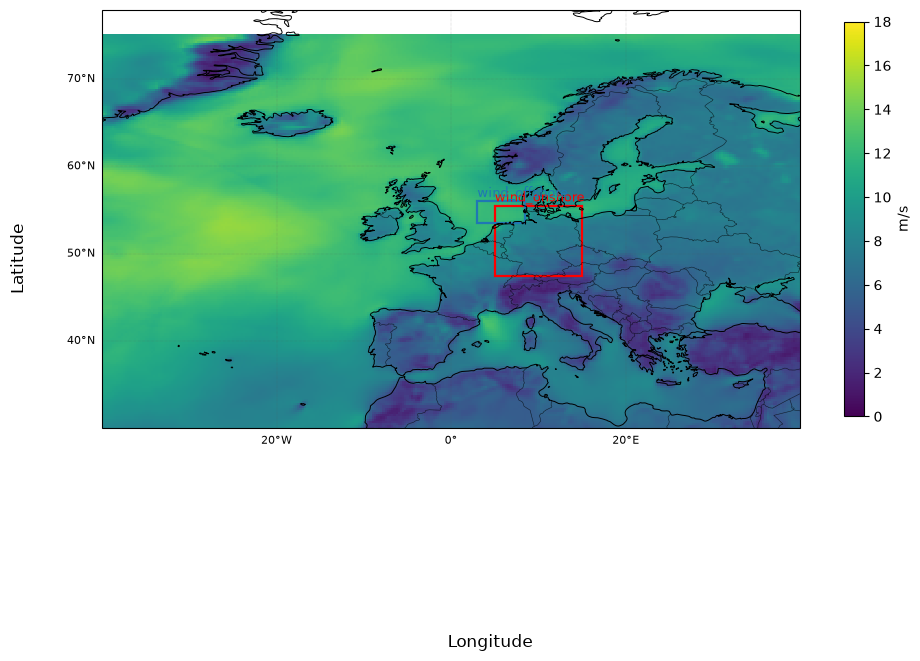

In [6]:
# Map the analysis domain: Jan-2023 mean ws100 shaded, fleet-proxy boxes as rectangles,
# political boundaries from Natural Earth.
ds = era5["2023-01"]
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": PC})
map_ax(ax, "ERA5 domain: Jan-2023 mean ws100 + fleet-proxy boxes")
ds.ws100.mean("time").plot.pcolormesh(
    ax=ax,
    transform=PC,
    cmap="viridis",
    vmin=0,
    vmax=18,
    add_colorbar=True,
    cbar_kwargs={"label": "m/s", "shrink": 0.6},
)
for (name, (la0, la1, lo0, lo1)), col in zip(FLEET_BOXES.items(), ["red", "tab:blue"], strict=True):
    ax.add_patch(
        mpatches.Rectangle(
            (lo0, la0),
            lo1 - lo0,
            la1 - la0,
            fill=False,
            ec=col,
            lw=1.6,
            transform=PC,
        )
    )
    ax.text(lo0, la1 + 0.5, name, color=col, fontsize=9, transform=PC)
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
plt.tight_layout(rect=[0.03, 0.08, 1, 0.98])
plt.show()

*Figure — ERA5 January-2023 mean 100 m wind speed over the analysis domain*
*(ARCO-ERA5, 0.25°, local Zarr cache `data/era5/`). Coastlines and country borders:*
*Natural Earth 50 m. Red/blue rectangles: onshore/offshore fleet-proxy boxes used by the*
*Phase 03 transfer function. Axes are longitude/latitude in degrees.*


### 1.2 The wind resource — general checks

**Left: time-mean speed** — expect maxima over the North Atlantic / North Sea, sharp
orographic reduction over the Alps and Scandinavia. **Right: temporal standard deviation** —
where the wind *varies*; storm tracks show up here, and variability is what drives
ramps and droughts.


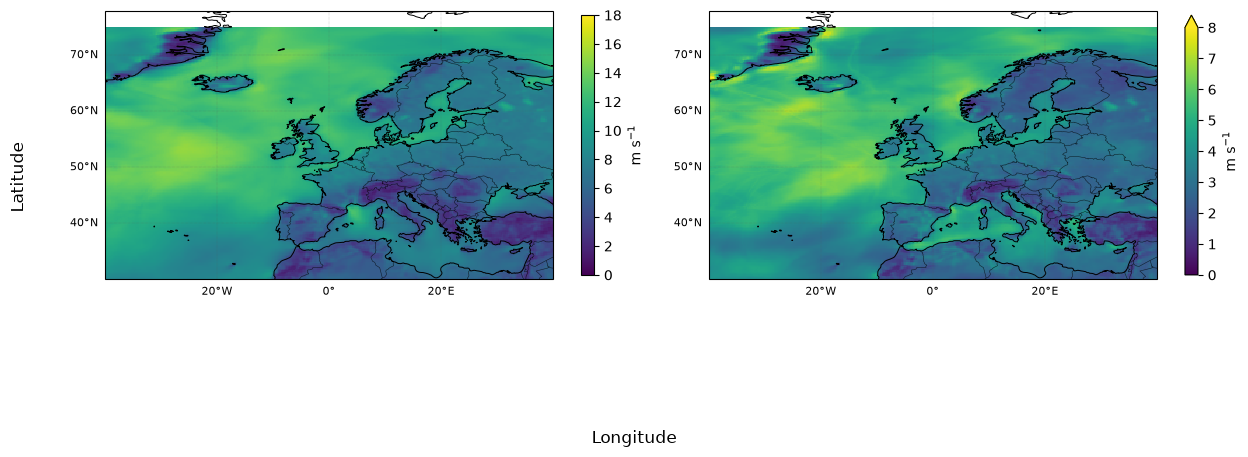

In [7]:
# Wind-resource maps: show the mean field first, then the hour-to-hour variability field.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), subplot_kw={"projection": PC})
for ax, (da, ttl, vmax) in zip(
    axes,
    [
        (ds.ws100.mean("time"), "Mean 100 m wind speed — Jan 2023", 18),
        (ds.ws100.std("time"), "Temporal variability of 100 m wind speed — Jan 2023", 8),
    ],
    strict=True,
):
    map_ax(ax, ttl)
    da.plot.pcolormesh(
        ax=ax,
        transform=PC,
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": "m s$^{-1}$", "shrink": 0.6},
    )
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.tight_layout(rect=[0.03, 0.08, 1, 0.98])
plt.show()

*Figure — left: the average ERA5 100 m wind speed in each grid cell during January 2023; right: the temporal standard deviation of that hourly field. Source: ERA5 via ARCO, local Zarr cache; `ws100 = hypot(u100, v100)`. The first panel checks the spatial pattern of the downloaded wind resource, while the second checks where wind varies most through time. These are preliminary physical sanity checks, not a climatology: the short window is expected to show stronger winds over the Atlantic/North Sea and lower values over complex terrain. The figure uses longitude on the x-axis and latitude on the y-axis; the colorbars show wind speed or temporal variability in m s⁻¹.*


In [8]:
# Statistics for ws100 and surface pressure per window: mean, std, percentiles, NaN fraction.
stats = []
for w, d in era5.items():
    for v in ["ws100", "sp"]:
        a = d[v].values.ravel()
        stats.append(
            {
                "window": w,
                "variable": v,
                "mean": a.mean(),
                "std": a.std(),
                "p01": np.percentile(a, 1),
                "p50": np.percentile(a, 50),
                "p99": np.percentile(a, 99),
                "nan_frac": np.isnan(a).mean(),
            }
        )
stats_table = pl.DataFrame(stats)
print("Table — ERA5 value summaries by window and variable")
display(stats_table)

Table — ERA5 value summaries by window and variable


window,variable,mean,std,p01,p50,p99,nan_frac
str,str,f64,f64,f64,f64,f64,f64
"""2023-01""","""ws100""",9.198788,5.321138,0.785209,8.473738,23.304243,0.0
"""2023-01""","""sp""",98865.632812,5799.618652,68557.765625,100335.890625,103750.960938,0.0
"""2024-11..12""","""ws100""",8.886057,5.28858,0.751936,8.081741,23.301638,0.0
"""2024-11..12""","""sp""",99070.234375,5708.672363,69171.617188,100735.8125,103711.234375,0.0


**Table explanation.** **Table — ERA5 value summaries by window and variable** describes all finite grid-cell/hour values in each cached window. `mean` is the arithmetic average; `std` is the standard deviation, measuring spread around the mean; `p01`, `p50`, and `p99` are the 1st, 50th (median), and 99th percentiles; and `nan_frac` is the fraction of values that are missing or not finite. For `ws100`, units are m s⁻¹. For `sp`, units are Pa, so values near 100,000 Pa correspond to about 1,000 hPa. These are pooled grid-cell/hour summaries, not national or area-weighted means.


### From raw grid cells to an interpretable time series

The ERA5 file contains one `ws100` value for every **grid cell and hour**. Before plotting it, separate two questions:

1. What values occur anywhere in the spatial domain? The pooled histogram below answers this, but every cell-hour has equal weight.
2. How does the average resource over the whole domain change with time? For this, average over latitude and longitude at each hour before plotting.

The table below is an intermediate check. It reports the spatial mean of each hourly field, rather than mixing all locations and times together.


In [9]:
# Intermediate check: summarise the hourly spatial mean before plotting the two different views.
domain_rows = []
for w, d in era5.items():
    hourly_mean = d.ws100.mean(("lat", "lon"))
    domain_rows.append(
        {
            "window": w,
            "hours": hourly_mean.sizes["time"],
            "mean_of_hourly_means_m_s": float(hourly_mean.mean()),
            "minimum_hourly_mean_m_s": float(hourly_mean.min()),
            "maximum_hourly_mean_m_s": float(hourly_mean.max()),
            "missing_hourly_means": int(hourly_mean.isnull().sum()),
        }
    )
domain_table = pl.DataFrame(domain_rows)
print("Table — hourly spatial-mean wind summary by cached window")
display(domain_table)

Table — hourly spatial-mean wind summary by cached window


window,hours,mean_of_hourly_means_m_s,minimum_hourly_mean_m_s,maximum_hourly_mean_m_s,missing_hourly_means
str,i64,f64,f64,f64,i64
"""2023-01""",744,9.198788,7.386324,10.286648,0
"""2024-11..12""",1464,8.886056,6.951897,11.425766,0


**Table explanation.** **Table — hourly spatial-mean wind summary by cached window** separates the time-series question from the pooled-value histogram. `hours` is the number of hourly timestamps; `mean_of_hourly_means_m_s` is the average of the hourly spatial means; the minimum and maximum columns show the weakest and strongest regional-average hours; and `missing_hourly_means` counts hours with a missing regional mean. This is an exploratory unweighted average used to make the time-series check transparent.


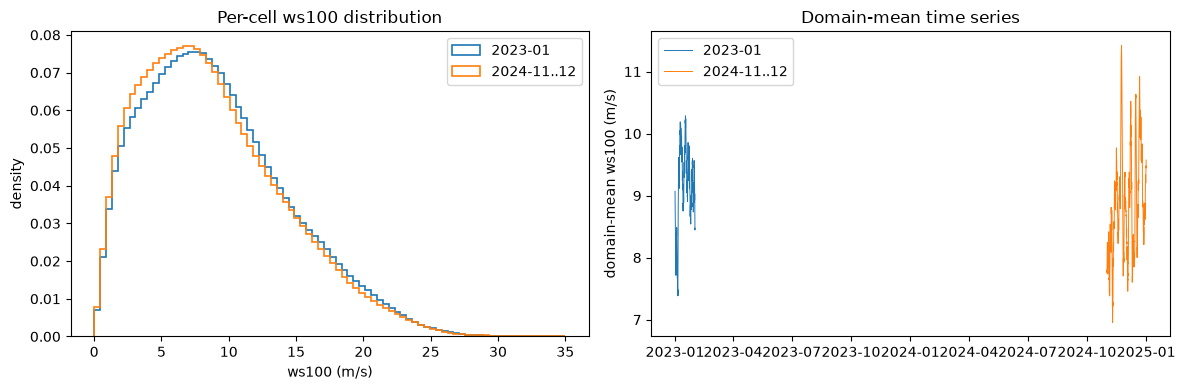

In [10]:
# ws100 distribution (all cells x hours, normalised) and domain-mean time series per window.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for w, d in era5.items():
    axes[0].hist(
        d.ws100.values.ravel(),
        bins=80,
        range=(0, 35),
        histtype="step",
        lw=1.2,
        density=True,
        label=w,
    )
    axes[1].plot(d.time.values, d.ws100.mean(("lat", "lon")).values, lw=0.7, label=w)
axes[0].set(xlabel="ws100 (m/s)", ylabel="density", title="Per-cell ws100 distribution")
axes[0].legend()
axes[1].set(ylabel="domain-mean ws100 (m/s)", title="Domain-mean time series")
axes[1].legend()
fig.tight_layout()
plt.show()

*Figure — two complementary ERA5/ARCO checks for the downloaded `ws100` field. Left: every grid-cell/hour value is pooled, so this answers “what wind speeds occur anywhere in the domain?” but gives large areas more weight than a domain average. Right: the spatial mean is computed at each hour first, so this answers “how did the domain-wide average resource evolve?” Source: local ERA5 Zarr caches, January 2023 and November–December 2024; no values are missing. The histogram is descriptive and not a probability distribution for a particular location; the time series is the better view for identifying broad calm or windy periods.

### 1.3 What is the Tibaldi–Molteni (TM1990) blocking index?

The **Tibaldi–Molteni index** is a rule for identifying a persistent atmospheric blocking pattern from the 500 hPa geopotential-height field. It does not look for “high pressure” at one point. Instead, it checks whether the usual decrease of height from south to north becomes reversed around a longitude:

- `GHGS` measures the height gradient between roughly 40°N and 60°N.
- `GHGN` measures the gradient between roughly 60°N and 80°N.
- A blocked longitude has `GHGS > 0` and `GHGN < -10 m per degree latitude` for at least one ±5° latitude offset.
- An event must then persist for at least five days and cover a contiguous longitude sector.

In plain language: the index searches for a strong, elongated mid-latitude ridge whose circulation pattern is displaced and persistent enough to interrupt the normal west-to-east flow. The notebook is only introducing the input field here; the full event detector belongs to the later diagnostics phase.

#### First learn to read the input field

`z500` is **geopotential height**: the height, measured in metres, of a constant-pressure surface. For `z500`, that surface is where air pressure equals 500 hPa, roughly the mid-troposphere at about 5.5 km above sea level. Higher geopotential height means that the 500 hPa pressure surface is physically higher; lower height means it is lower. Its north-south shape reveals ridges and troughs, and the near-geostrophic flow at that level helps steer surface weather.

How to read the map:
- **Contours bulging northward** indicate a ridge, usually associated with a broad area of descending and more settled air.
- **Contours dipping southward** indicate a trough, usually associated with colder or more unsettled air.
- **Tight contour spacing** indicates a stronger horizontal pressure-gradient force and faster flow.
- The instantaneous field below is the kind of field a blocking index evaluates; a time mean is useful context but is not itself an event detector.


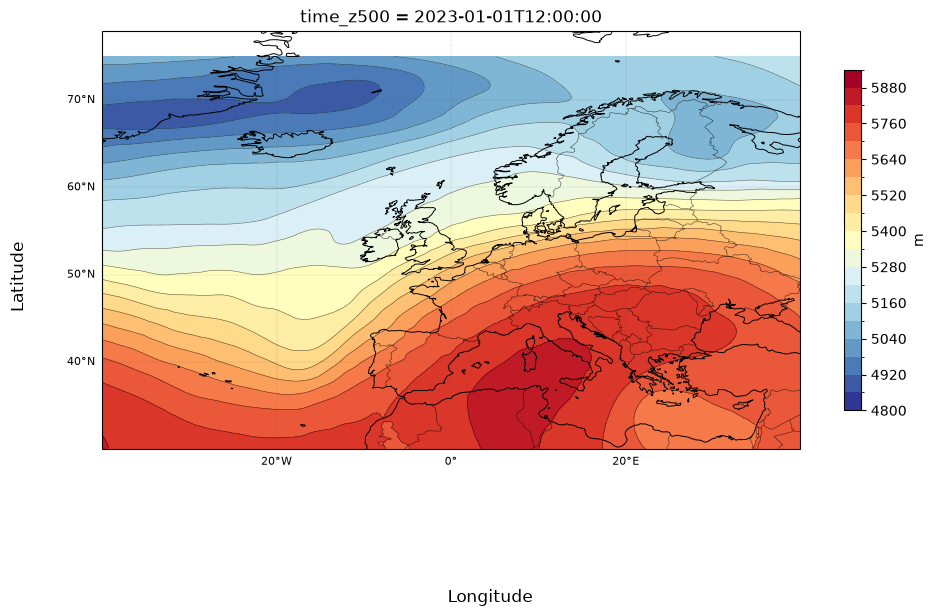

In [11]:
# One instantaneous Z500 field: 2023-01-01 12 UTC. Filled + line contours, 60 m interval.
ds = era5["2023-01"]
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": PC})
z = ds.z500.sel(time_z500="2023-01-01T12")
map_ax(ax, "Z500 snapshot, 2023-01-01 12 UTC")
z.plot.contourf(
    ax=ax,
    transform=PC,
    levels=range(4800, 6000, 60),
    cmap="RdYlBu_r",
    add_colorbar=True,
    cbar_kwargs={"label": "m", "shrink": 0.6},
)
z.plot.contour(ax=ax, transform=PC, levels=range(4800, 6000, 60), colors="k", linewidths=0.4, alpha=0.6)
fig.supxlabel("Longitude", y=0.03)
fig.supylabel("Latitude", x=0.02)
fig.tight_layout(rect=[0.03, 0.08, 1, 0.98])
plt.show()

*Figure — ERA5 500 hPa geopotential height at the single 6-hourly timestep 2023-01-01 12 UTC. Source: ERA5 via ARCO, local Zarr cache. The shaded field and black contours show the height, in metres, of the surface where atmospheric pressure equals 500 hPa. This is an instantaneous weather pattern—not a time mean and not a blocking classification. The Tibaldi–Molteni diagnostic later evaluates this field using north–south height gradients, longitude-sector continuity, and persistence. Longitude is on the x-axis, latitude is on the y-axis, and the contour interval is 60 m.*


**Then the mean.** Time averaging smooths moving synoptic systems and leaves the average circulation pattern for each short window. This is useful for comparing the two downloads, but it should not be read as a blocking event. The TM1990 detector operates on each 6-hourly field, applies the meridional-gradient rule above, and then applies persistence and longitude-sector criteria. The mean map is therefore a context check, not the result of the blocking analysis.


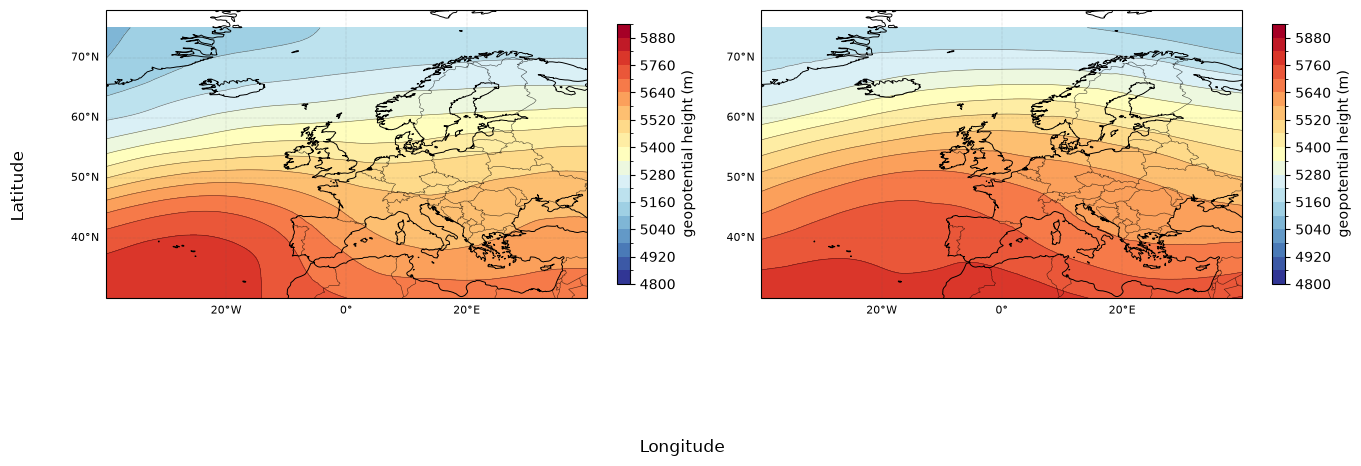

In [12]:
# Mean Z500 maps: compare the average circulation structure while retaining explicit map coordinates.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), subplot_kw={"projection": PC})
for ax, w in zip(axes, era5, strict=True):
    z = era5[w].z500.mean("time_z500")
    map_ax(ax, f"Mean 500 hPa geopotential height — {w}")
    z.plot.contourf(
        ax=ax,
        transform=PC,
        levels=range(4800, 6000, 60),
        cmap="RdYlBu_r",
        add_colorbar=True,
        cbar_kwargs={"label": "geopotential height (m)", "shrink": 0.6},
    )
    z.plot.contour(
        ax=ax,
        transform=PC,
        levels=range(4800, 6000, 60),
        colors="k",
        linewidths=0.4,
        alpha=0.6,
    )
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.tight_layout(rect=[0.03, 0.08, 1, 0.98])
plt.show()

*Figure — short-window mean 500 hPa geopotential height for January 2023 (left) and November–December 2024 (right), from ERA5 via ARCO. Each panel averages the 6-hourly `z500` fields within its cached window, so it shows the typical circulation shape during that window rather than a single weather event. Contours are separated by 60 m and the color shading gives geopotential height in metres. These panels are context and download sanity checks; the later TM1990 blocking test must use the individual 6-hourly fields, then apply its gradient, longitude-sector, and persistence rules.

### 1.4 Surface pressure

Downloaded for a later purpose: where a climate model's 1000 hPa level would sit below
ground, its near-100 m wind is invalid — `sp` is how we flag that. Check: near 101 kPa
over sea, well below at altitude; no NaNs (see stats table above).


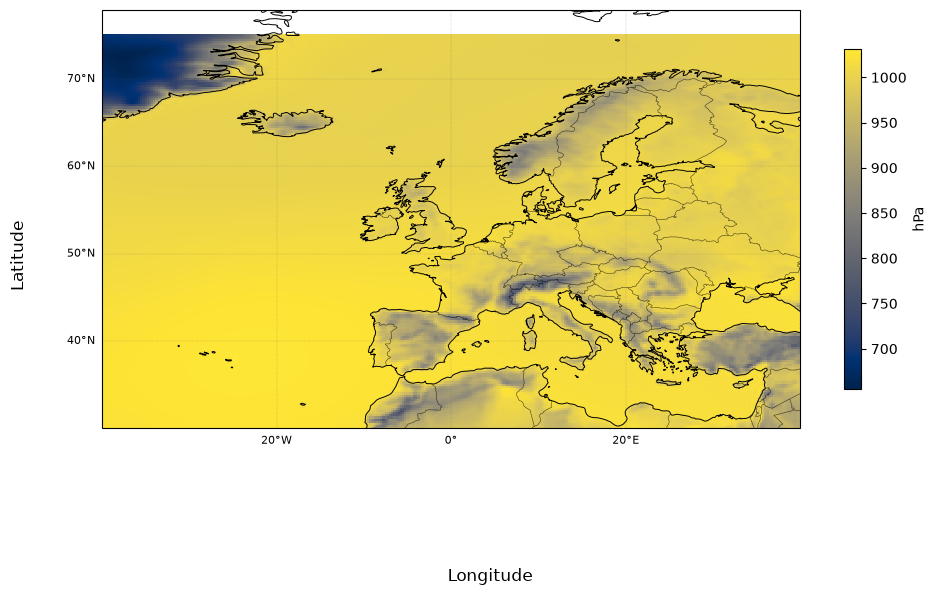

In [13]:
# Mean surface-pressure map (hPa) for Jan 2023.
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": PC})
map_ax(ax, "Mean surface pressure, Jan 2023")
(ds.sp.mean("time") / 100).plot.pcolormesh(
    ax=ax,
    transform=PC,
    cmap="cividis",
    add_colorbar=True,
    cbar_kwargs={"label": "hPa", "shrink": 0.6},
)
fig.supxlabel("Longitude", y=0.03)
fig.supylabel("Latitude", x=0.02)
fig.tight_layout(rect=[0.03, 0.08, 1, 0.98])
plt.show()

*Figure — Jan-2023 mean surface pressure (ERA5/ARCO), hPa. Low values over the Alps and*
*Norway mark where a climate-model 1000 hPa level would sit underground.*


## 2. SMARD — where it comes from and what was downloaded

The Bundesnetzagentur's market-data API (`https://www.smard.de/app/chart_data`) — actual
metered feed-in per TSO zone, the ground truth the transfer function is validated against. We downloaded **generation and installed
capacity**, hourly, wind onshore/offshore/solar, all four zones, both windows. Capacity is
needed because the metric that matters is *capacity factor* (generation ÷ capacity at that
moment), and the fleet grew over the period. Values are MWh/interval, which at hourly
cadence equals mean MW.

Provenance caveat: generation filter IDs are public; capacity IDs (186/187/188) were
**inferred** by matching Germany-wide yearly totals to known capacities. The step plots
below are the check: roughly ~60 GW onshore, ~9 GW offshore, ~90 GW PV expected by 2024.


In [14]:
# Download SMARD generation + installed capacity for both windows; per-zone inventory
# (row counts, nulls, mean and max MW).
smard = SmardClient(cache_dir=cfg["smard"]["cache_dir"])
frames = {}
for w, (s, e) in WINDOWS.items():
    s, e = datetime.fromisoformat(s), datetime.fromisoformat(e)
    frames[w] = {
        "gen": smard.load_generation(s, e),
        "cap": smard.load_installed_capacity(s, e),
        "cf": None,  # filled below
    }
    frames[w]["cf"] = capacity_factor(frames[w]["gen"], frames[w]["cap"])

inv = []
for w, f in frames.items():
    for kind in ("gen", "cap"):
        g = (
            f[kind]
            .group_by("zone", "variable")
            .agg(
                n=pl.len(),
                nulls=pl.col("value_mw").null_count(),
                mean_mw=pl.col("value_mw").mean(),
                max_mw=pl.col("value_mw").max(),
            )
        )
        inv += [dict(window=w, kind=kind, **r) for r in g.to_dicts()]
pl.DataFrame(inv).sort("window", "kind", "zone", "variable")

window,kind,zone,variable,n,nulls,mean_mw,max_mw
str,str,str,str,i64,i64,f64,f64
"""2023-01""","""cap""","""50Hertz""","""solar""",744,0,16250.0,16250.0
"""2023-01""","""cap""","""50Hertz""","""wind_offshore""",744,0,1093.0,1093.0
"""2023-01""","""cap""","""50Hertz""","""wind_onshore""",744,0,20756.0,20756.0
"""2023-01""","""cap""","""Amprion""","""solar""",744,0,14475.0,14475.0
"""2023-01""","""cap""","""Amprion""","""wind_offshore""",744,0,0.0,0.0
…,…,…,…,…,…,…,…
"""2024-11..12""","""gen""","""TenneT""","""wind_offshore""",1464,0,2505.301742,6066.5
"""2024-11..12""","""gen""","""TenneT""","""wind_onshore""",1464,0,7030.605874,19195.0
"""2024-11..12""","""gen""","""TransnetBW""","""solar""",1464,0,323.635587,3208.5


### 2.0a SMARD time-axis, missingness, and value-range checks

The SMARD client converts source timestamps to **UTC**, loads the hourly interval values, removes duplicate weekly-file overlaps, and keeps missing observations as nulls. The table below checks what remains after those steps for every zone and technology:

- expected number of hourly records;
- duplicate timestamps and unexpected time gaps;
- null observations;
- negative generation or capacity values;
- capacity-factor values outside the physical range 0–1.

Offshore capacity is expected to be exactly zero in Amprion and TransnetBW because those inland TSO zones have no offshore feed-in series. Those zeros are structural, not missing data.


In [15]:
# Check SMARD hourly coverage, timestamp continuity, value ranges, and capacity-factor bounds.
smard_quality = []
for w, (start, end) in WINDOWS.items():
    start_dt, end_dt = datetime.fromisoformat(start), datetime.fromisoformat(end)
    expected_hours = int((end_dt - start_dt).total_seconds() // 3600)
    for kind in ["gen", "cap"]:
        frame = frames[w][kind]
        for (zone, variable), group in frame.group_by(["zone", "variable"], maintain_order=True):
            times = group["time"].sort().to_list()
            diffs = np.diff(np.array(times, dtype="datetime64[h]")).astype("timedelta64[h]").astype(int)
            values = group["value_mw"].to_numpy()
            smard_quality.append(
                {
                    "window": w,
                    "kind": kind,
                    "zone": zone,
                    "variable": variable,
                    "rows": len(times),
                    "expected_rows": expected_hours,
                    "row_shortfall": expected_hours - len(times),
                    "duplicate_timestamps": len(times) - len(set(times)),
                    "unexpected_hour_steps": int(np.sum(diffs != 1)) if diffs.size else 0,
                    "null_values": int(np.isnan(values).sum()),
                    "negative_values": int(np.sum(np.nan_to_num(values, nan=0.0) < 0)),
                    "minimum_mw": float(np.nanmin(values)),
                    "maximum_mw": float(np.nanmax(values)),
                }
            )

for w, frame in frames.items():
    cf = frame["cf"]
    invalid = cf.filter(
        pl.col("capacity_factor").is_not_null()
        & ((pl.col("capacity_factor") < 0) | (pl.col("capacity_factor") > 1))
    )
    smard_quality.append(
        {
            "window": w,
            "kind": "capacity_factor",
            "zone": "all",
            "variable": "all",
            "rows": cf.height,
            "expected_rows": None,
            "row_shortfall": None,
            "duplicate_timestamps": None,
            "unexpected_hour_steps": None,
            "null_values": cf["capacity_factor"].null_count(),
            "negative_values": invalid.height,
            "minimum_mw": float(cf["capacity_factor"].min()),
            "maximum_mw": float(cf["capacity_factor"].max()),
        }
    )
pl.DataFrame(smard_quality).sort(["window", "kind", "zone", "variable"])

/tmp/ipykernel_10614/255097425.py:10: UserWarning: no explicit representation of timezones available for np.datetime64
  diffs = np.diff(np.array(times, dtype="datetime64[h]")).astype("timedelta64[h]").astype(int)


window,kind,zone,variable,rows,expected_rows,row_shortfall,duplicate_timestamps,unexpected_hour_steps,null_values,negative_values,minimum_mw,maximum_mw
str,str,str,str,i64,i64,i64,i64,i64,i64,i64,f64,f64
"""2023-01""","""cap""","""50Hertz""","""solar""",744,744,0,0,0,0,0,16250.0,16250.0
"""2023-01""","""cap""","""50Hertz""","""wind_offshore""",744,744,0,0,0,0,0,1093.0,1093.0
"""2023-01""","""cap""","""50Hertz""","""wind_onshore""",744,744,0,0,0,0,0,20756.0,20756.0
"""2023-01""","""cap""","""Amprion""","""solar""",744,744,0,0,0,0,0,14475.0,14475.0
"""2023-01""","""cap""","""Amprion""","""wind_offshore""",744,744,0,0,0,0,0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-11..12""","""gen""","""TenneT""","""wind_offshore""",1464,1464,0,0,0,0,0,0.0,6066.5
"""2024-11..12""","""gen""","""TenneT""","""wind_onshore""",1464,1464,0,0,0,0,0,4.75,19195.0
"""2024-11..12""","""gen""","""TransnetBW""","""solar""",1464,1464,0,0,0,0,0,0.0,3208.5


*Table — structural quality checks for the cached SMARD observations. Source: SMARD API files loaded through the local parquet cache; timestamps are normalised to UTC by the client. A shortfall or unexpected time step indicates incomplete coverage rather than zero generation. The capacity-factor bounds check is applied only where installed capacity is positive; structural offshore zeros in inland zones remain explicitly identifiable.*


### 2.0b National generation and capacity summary

The per-zone inventory is useful for finding missing files, but the project also needs a compact national-level check. The table below sums the four TSO zones and reports the mean, maximum, upper percentile, and observed-hour coverage for each technology. It should be read as a description of these two short windows, not as a national climatology.


In [16]:
# Summarise Germany-wide observed generation and installed capacity for each window and technology.
national_rows = []
for w, frame in frames.items():
    generation = (
        frame["gen"].group_by(["time", "variable"]).agg(pl.col("value_mw").sum().alias("generation_mw"))
    )
    for variable, group in generation.group_by("variable", maintain_order=True):
        variable_name = variable[0] if isinstance(variable, tuple) else variable
        values = group["generation_mw"].to_numpy()
        national_rows.append(
            {
                "window": w,
                "variable": variable_name,
                "hours": group.height,
                "mean_generation_mw": float(np.nanmean(values)),
                "p99_generation_mw": float(np.nanpercentile(values, 99)),
                "maximum_generation_mw": float(np.nanmax(values)),
                "null_hours": int(np.isnan(values).sum()),
            }
        )
    capacity = frame["cap"].group_by(["time", "variable"]).agg(pl.col("value_mw").sum().alias("capacity_mw"))
    for variable, group in capacity.group_by("variable", maintain_order=True):
        variable_name = variable[0] if isinstance(variable, tuple) else variable
        values = group["capacity_mw"].to_numpy()
        national_rows.append(
            {
                "window": w,
                "variable": f"{variable_name}_capacity",
                "hours": group.height,
                "mean_generation_mw": float(np.nanmean(values)),
                "p99_generation_mw": float(np.nanpercentile(values, 99)),
                "maximum_generation_mw": float(np.nanmax(values)),
                "null_hours": int(np.isnan(values).sum()),
            }
        )
pl.DataFrame(national_rows)

window,variable,hours,mean_generation_mw,p99_generation_mw,maximum_generation_mw,null_hours
str,str,i64,f64,f64,f64,i64
"""2023-01""","""solar""",744,1107.936156,9210.0575,12223.5,0
"""2023-01""","""wind_offshore""",744,3670.257056,6746.6375,7072.25,0
"""2023-01""","""wind_onshore""",744,19690.779234,44325.455,45104.25,0
"""2023-01""","""solar_capacity""",744,63066.0,63066.0,63066.0,0
"""2023-01""","""wind_offshore_capacity""",744,8129.0,8129.0,8129.0,0
…,…,…,…,…,…,…
"""2024-11..12""","""solar""",1464,1753.111339,13844.72,23778.5,0
"""2024-11..12""","""wind_offshore""",1464,3209.763149,6477.6875,7397.5,0
"""2024-11..12""","""wind_onshore_capacity""",1464,59843.288934,59841.0,63192.0,0


*Table — Germany-wide summary of the cached SMARD series after summing the four TSO zones. Generation values are hourly mean MW; capacity values are the installed-capacity denominator. Source: SMARD API, converted to UTC and retained at hourly resolution. The two windows are too short to support a national long-term estimate.*


### 2.1 Installed capacity — the baseline used to calculate capacity factors

Installed capacity is the maximum rated power of the fleet, expressed here in GW. It is the **denominator** in a capacity factor:

\[
\mathrm{capacity\ factor} = \frac{\mathrm{generation\ (MW)}}{\mathrm{installed\ capacity\ (MW)}}.
\]

This check asks a simple question before we interpret generation: did the downloaded SMARD capacity series produce plausible fleet sizes, and are the totals split sensibly across the four TSO zones? It is not a check of how much electricity was generated. The left panel below shows where the fleet is assigned; the right panel shows the national installed-capacity baseline for each technology and window.


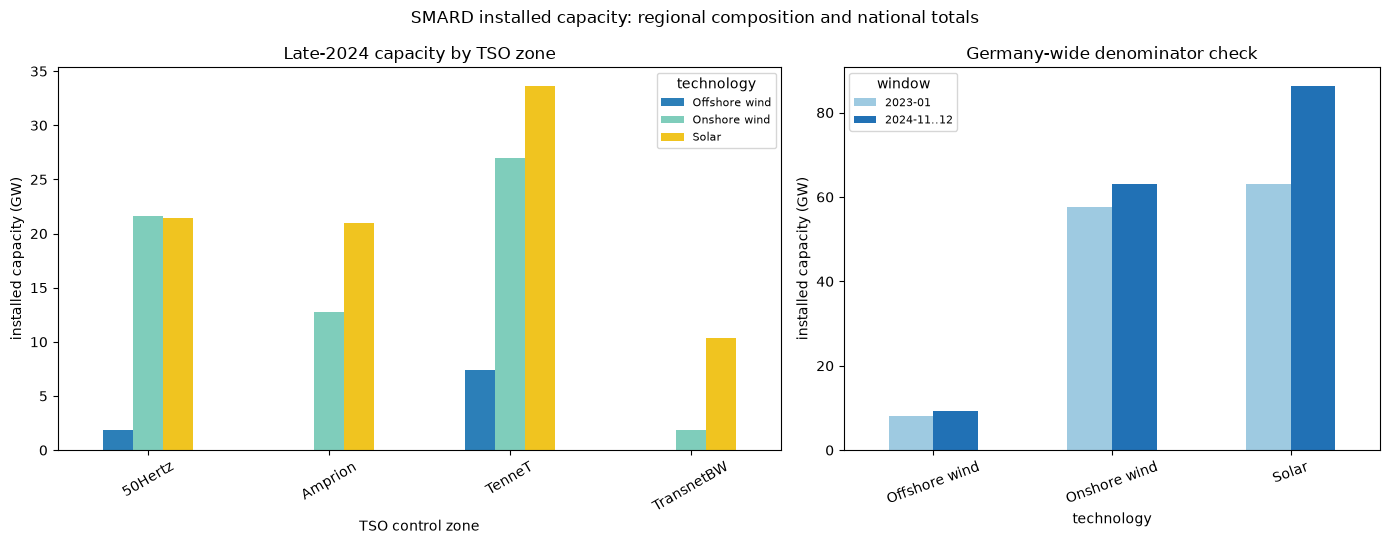

In [17]:
# Installed-capacity comparison: show late-2024 technology totals and their TSO-zone composition.
import pandas as pd

latest_rows = []
for w, f in frames.items():
    cap = f["cap"].to_pandas().sort_values("time")
    latest_rows.append(cap.groupby(["zone", "variable"], as_index=False).tail(1).assign(window=w))
latest = pd.concat(latest_rows, ignore_index=True)
latest["capacity_gw"] = latest["value_mw"] / 1000
latest["technology"] = latest["variable"].map(
    {"wind_onshore": "Onshore wind", "wind_offshore": "Offshore wind", "solar": "Solar"}
)
latest_2024 = latest[latest["window"] == "2024-11..12"]
totals = latest.groupby(["window", "technology"], as_index=False)["capacity_gw"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
latest_2024.pivot(index="zone", columns="technology", values="capacity_gw").plot(
    kind="bar", ax=axes[0], color=["#2c7fb8", "#7fcdbb", "#f0c420"]
)
axes[0].set(
    title="Late-2024 capacity by TSO zone",
    xlabel="TSO control zone",
    ylabel="installed capacity (GW)",
)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="technology", fontsize=8)

totals.pivot(index="technology", columns="window", values="capacity_gw").plot(
    kind="bar", ax=axes[1], color=["#9ecae1", "#2171b5"]
)
axes[1].set(
    title="Germany-wide denominator check",
    xlabel="technology",
    ylabel="installed capacity (GW)",
)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="window", fontsize=8)
fig.suptitle("SMARD installed capacity: regional composition and national totals")
fig.tight_layout()
plt.show()

*Figure — a more useful installed-capacity check from the SMARD API. Left: late-2024 capacity split across the four TSO control zones and three technologies. Right: Germany-wide totals at the end of each downloaded window. Source: SMARD installed-capacity series using filter IDs 186/187/188; those capacity mappings are documented as inferred from known totals. This figure is a denominator and coverage check for later capacity factors, not a power-generation result. The zone bars explain why one national total cannot be interpreted as a uniform spatial fleet: each TSO aggregates a different part of Germany.

### 2.2 Spatial view — installed capacity by zone

SMARD reports **zonal aggregates**, not plant coordinates, so the honest spatial figure
is bubbles at (approximate) zone centroids sized by installed capacity — one panel per
technology. Offshore bubbles are placed over the sea each zone actually feeds
(50Hertz → Baltic, TenneT → North Sea). True plant-level spatial resolution is the
planned MaStR addition.


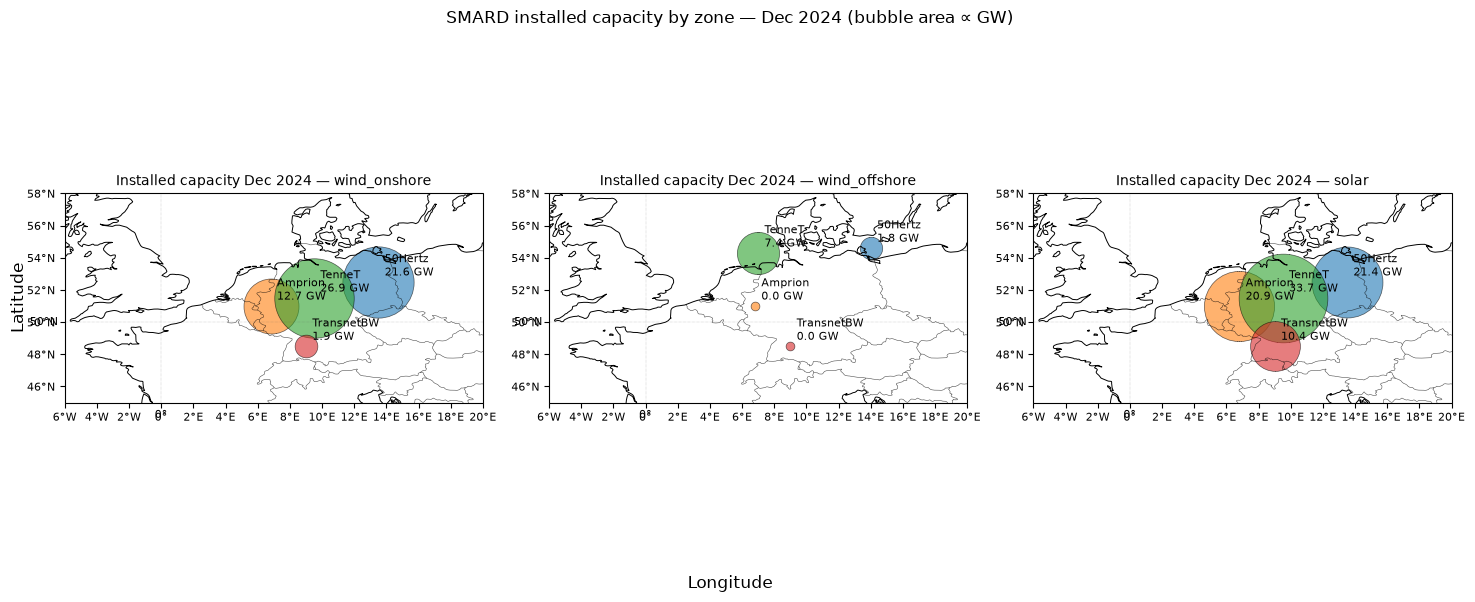

In [18]:
# Zonal installed-capacity map: bubble at each zone's approximate centroid, sized by GW,
# separately per technology. Offshore bubbles at sea (50Hertz=Baltic, TenneT=North Sea).
CENTROIDS = {  # approximate TSO-zone centroids (lat, lon), display only
    "50Hertz": (52.5, 13.5),
    "TenneT": (51.5, 9.5),
    "Amprion": (51.0, 6.8),
    "TransnetBW": (48.5, 9.0),
}
OFFSHORE_SEA = {"50Hertz": (54.6, 14.0), "TenneT": (54.3, 7.0)}  # Baltic / North Sea

fig, axes = plt.subplots(1, 3, figsize=(15, 6), subplot_kw={"projection": PC})
for ax, var in zip(axes, ["wind_onshore", "wind_offshore", "solar"], strict=True):
    map_ax(ax, f"Installed capacity Dec 2024 — {var}")
    cap = frames["2024-11..12"]["cap"].filter(
        pl.col("variable") == var, pl.col("time") == pl.col("time").max()
    )
    for r in cap.iter_rows(named=True):
        z, v = r["zone"], r["value_mw"] / 1000
        lat, lon = OFFSHORE_SEA.get(z, CENTROIDS[z]) if var == "wind_offshore" else CENTROIDS[z]
        ax.scatter(lon, lat, s=40 + v * 120, transform=PC, alpha=0.6, edgecolors="k", lw=0.5)
        ax.text(lon + 0.4, lat + 0.4, f"{z}\n{v:.1f} GW", fontsize=8, transform=PC)
    ax.set_xlim(-6, 20)
    ax.set_ylim(45, 58)
    ax.set_xticks(range(-6, 21, 2), crs=PC)
    ax.set_yticks(range(46, 59, 2), crs=PC)
    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
    ax.tick_params(labelsize=8)
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.suptitle("SMARD installed capacity by zone — Dec 2024 (bubble area ∝ GW)")
fig.tight_layout()
plt.show()

*Figure — SMARD installed capacity by TSO control zone in December 2024. Each bubble is an approximate display centroid for a zonal aggregate, not a plant location; bubble area is proportional to capacity. The map uses 2° longitude and latitude ticks. Offshore bubbles are placed in the Baltic/North Sea feed-in areas only to make the two relevant zones visible. The southern zones show structural zero offshore capacity in this SMARD series. Source: SMARD installed-capacity API; true plant-level geography would require MaStR data.

### 2.3 Observed generation — the signal being modelled

**Germany-total hourly wind + solar generation** in each window. This is the shape of the
problem: deep multi-day wind holes (the dark lulls) embedded in highly variable output,
and solar contributing almost nothing in winter. The near-zero stretches are the
Dunkelflaute events this project studies.


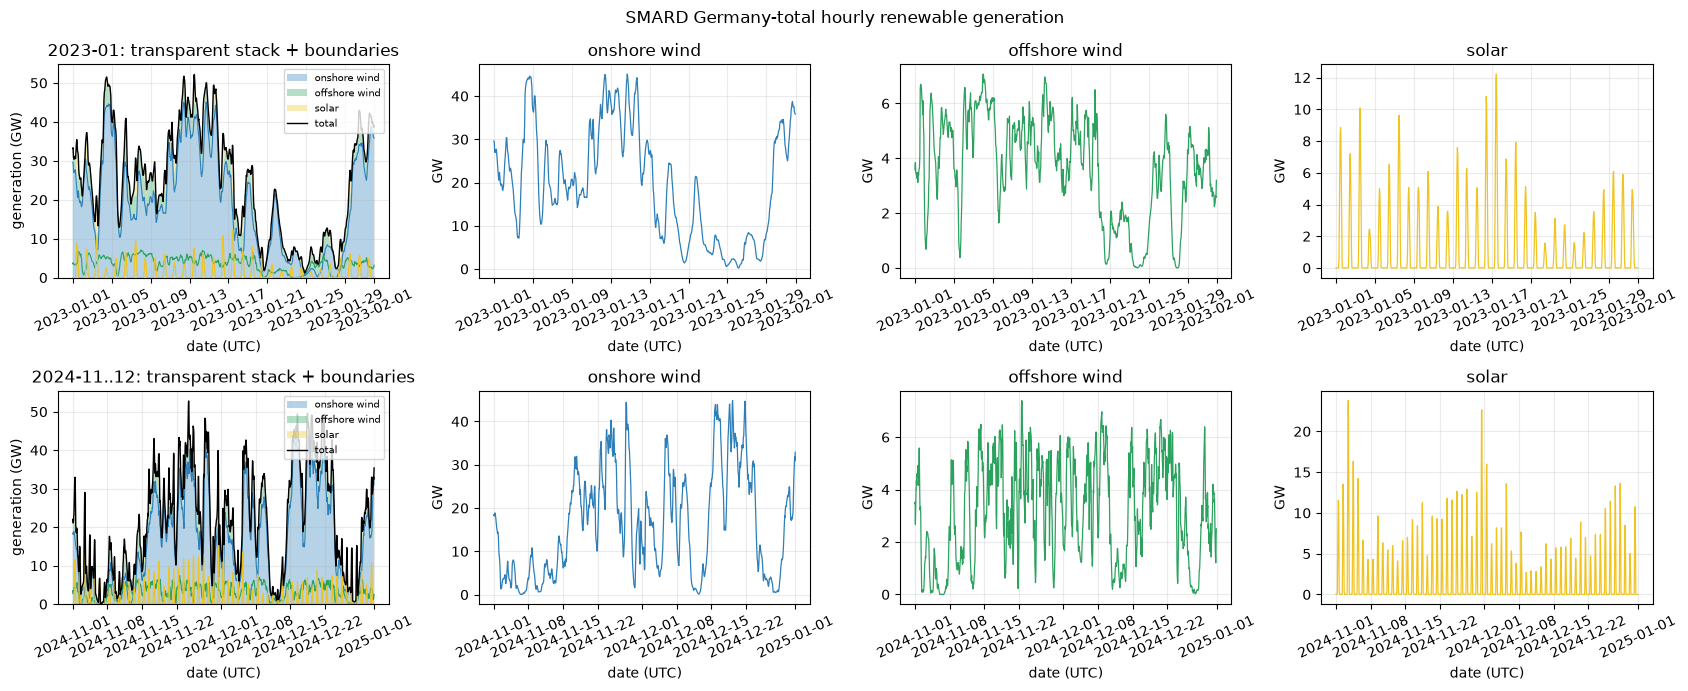

In [19]:
# Generation readability check: combine a transparent stack with one separate line panel per technology.
fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharex=False, squeeze=False)
colors = {"wind_onshore": "#2c7fb8", "wind_offshore": "#2ca25f", "solar": "#f0c420"}
labels = {"wind_onshore": "onshore wind", "wind_offshore": "offshore wind", "solar": "solar"}
for row, (w, f) in enumerate(frames.items()):
    nat = (
        f["gen"]
        .group_by("time", "variable")
        .agg(pl.col("value_mw").sum())
        .to_pandas()
        .pivot(index="time", columns="variable", values="value_mw")
        .fillna(0)
        / 1000
    )
    for var in colors:
        if var not in nat:
            nat[var] = 0.0
    total = nat[list(colors)].sum(axis=1)
    axes[row, 0].stackplot(
        nat.index,
        *(nat[var] for var in colors),
        labels=[labels[var] for var in colors],
        colors=[colors[var] for var in colors],
        alpha=0.35,
    )
    for var in colors:
        axes[row, 0].plot(nat.index, nat[var], color=colors[var], lw=0.8)
    axes[row, 0].plot(nat.index, total, color="black", lw=1.0, label="total")
    axes[row, 0].set_title(f"{w}: transparent stack + boundaries")
    axes[row, 0].legend(loc="upper right", fontsize=7)
    axes[row, 0].set_ylabel("generation (GW)")
    for col, var in enumerate(colors, start=1):
        axes[row, col].plot(nat.index, nat[var], color=colors[var], lw=0.9)
        axes[row, col].set_title(labels[var])
        axes[row, col].set_ylabel("GW")
        axes[row, col].grid(alpha=0.25)
    for ax in axes[row]:
        ax.set_xlabel("date (UTC)")
        ax.tick_params(axis="x", rotation=25)
        ax.grid(alpha=0.25)
fig.suptitle("SMARD Germany-total hourly renewable generation")
fig.tight_layout()
plt.show()

*Figure — Germany-total hourly renewable generation from SMARD. The left column keeps the technology composition but uses transparent fills, boundary lines, and a black total line. The three panels to the right isolate onshore wind, offshore wind, and solar so one technology cannot hide another through overlap. Source: SMARD generation series summed over all four TSO zones; values are shown as mean GW per hourly interval. These plots are an initial signal check: visible calm periods motivate later Dunkelflaute analysis, but this short coverage is not enough to estimate a climatological frequency.

### 2.4 Capacity factors per zone

The distribution of CF per zone and window — **this is what the transfer function must**
**reproduce.** Offshore sits higher and tighter than onshore; Nov–Dec 2024 shifts down
visibly (the lulls); solar ~2% winter CF. Amprion/TransnetBW offshore are structurally zero.


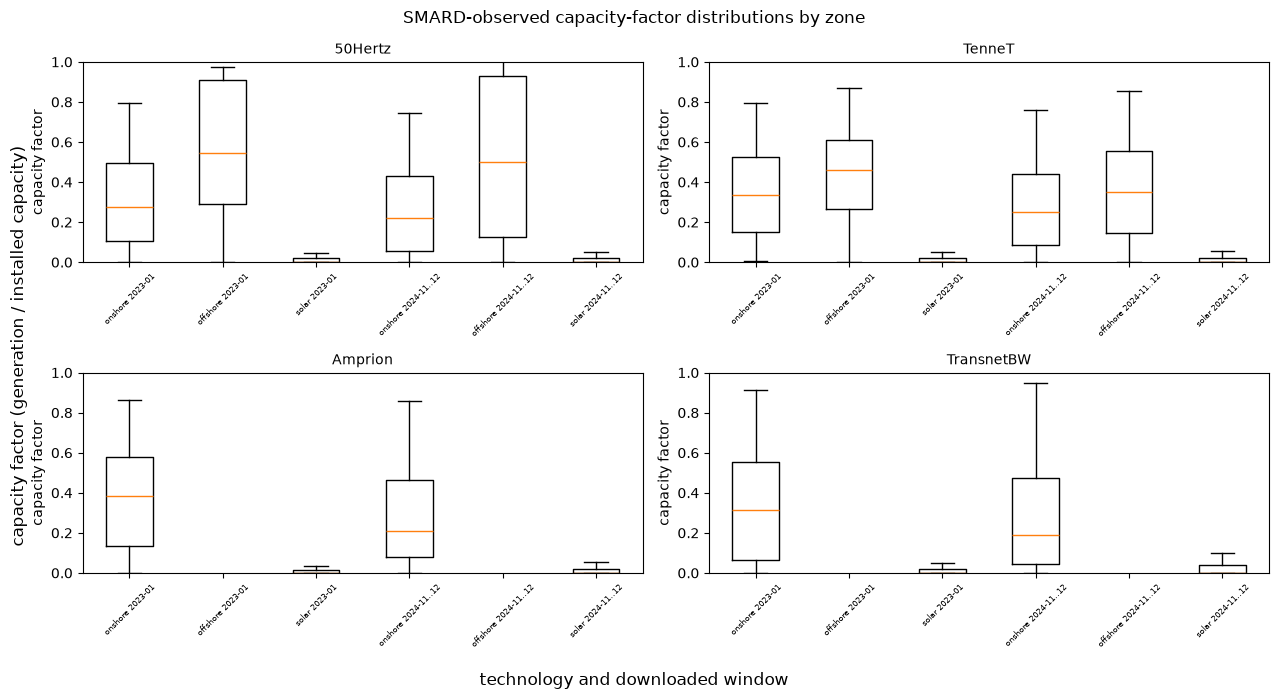

In [20]:
# Per-zone CF boxplots: both windows x all three technologies.
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
zones = ["50Hertz", "TenneT", "Amprion", "TransnetBW"]
for ax, zone in zip(axes.ravel(), zones, strict=True):
    data, labels = [], []
    for w, f in frames.items():
        for var in ["wind_onshore", "wind_offshore", "solar"]:
            s = (
                f["cf"]
                .filter(pl.col("zone") == zone, pl.col("variable") == var)["capacity_factor"]
                .drop_nans()
            )
            data.append(s.to_numpy())
            labels.append(f"{var.replace('wind_', '')} {w}")
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_ylim(0, 1)
    ax.set_title(zone, fontsize=10)
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.set_ylabel("capacity factor")
fig.supxlabel("technology and downloaded window")
fig.supylabel("capacity factor (generation / installed capacity)")
fig.suptitle("SMARD-observed capacity-factor distributions by zone")
fig.tight_layout()
plt.show()

*Figure — SMARD-observed capacity-factor distributions per zone (box = IQR, whiskers,*
*outliers hidden), both windows. This is the target distribution the transfer model must*
*reproduce.*


**Gaps and quirks worth knowing:**
- Occasional `null` hours in the feed (see `nulls` column above) — real gaps, kept as null not zero.
- Generation is MWh/interval; hourly equals mean MW. Quarter-hourly is available but not downloaded.
- Solar stays observed-only: no radiation variable is downloaded, so it has no transfer function.



## 3. Coverage summary — downloaded vs. planned

| | on disk | planned (later phases) |
|---|---|---|
| ERA5 | ws100/u100/v100/sp hourly + z500 6h, Jan 2023 + Nov–Dec 2024, 30–75°N / 40°W–40°E | extend windows for the 30-yr blocking climatology |
| SMARD | hourly gen + capacity, 4 zones, Jan 2023 + Nov–Dec 2024 | quarter-hourly if ramp analysis needs it |
| EERIE | *nothing yet* | 3-D u/v/z pressure levels (6h), 2-D sp/gusts; hist-1950 + ssp245, Phase 06 gated on the ERA5 pipeline |
| MaStR | *nothing* | turbine locations for capacity-weighted aggregation (biggest known transfer bias) |

Reading order for the science: ERA5 + SMARD are the calibration pair. EERIE only enters after
the same diagnostics reproduce ERA5's known answers — that is the evaluative logic of the project.
